In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print(matches.head())
print(deliveries.head())

       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkat

In [6]:
# Check null values
print(matches.isnull().sum())

# Fill or drop missing values
matches = matches.dropna()

# Convert date column
matches['date'] = pd.to_datetime(matches['date'])

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


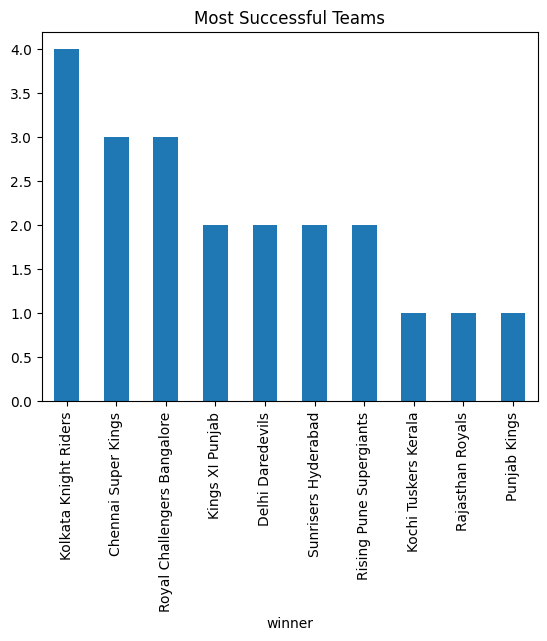

In [7]:
matches['winner'].value_counts().plot(kind='bar')
plt.title("Most Successful Teams")
plt.show()

In [8]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winner']]
print(len(toss_win_match_win) / len(matches))

0.5238095238095238


In [9]:
top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print(top_scorers)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


In [10]:
top_bowlers = deliveries['bowler'].value_counts().head(10)
print(top_bowlers)

bowler
R Ashwin           4679
SP Narine          4146
B Kumar            4060
RA Jadeja          3895
PP Chawla          3895
YS Chahal          3628
Harbhajan Singh    3496
A Mishra           3444
DJ Bravo           3296
UT Yadav           3190
Name: count, dtype: int64


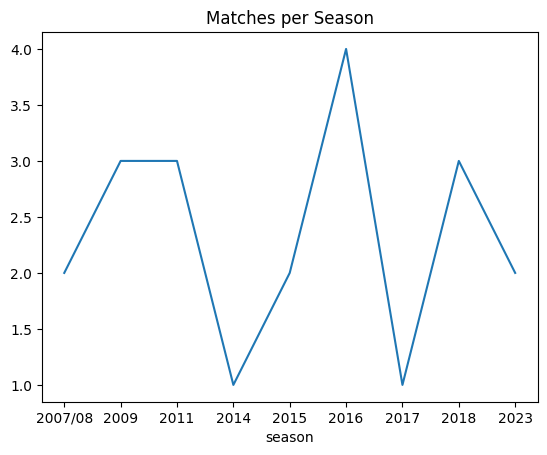

In [11]:
matches['season'].value_counts().sort_index().plot()
plt.title("Matches per Season")
plt.show()

In [12]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winner']]
ratio = len(toss_win_match_win) / len(matches)

print("Toss win → Match win ratio:", ratio)

Toss win → Match win ratio: 0.5238095238095238


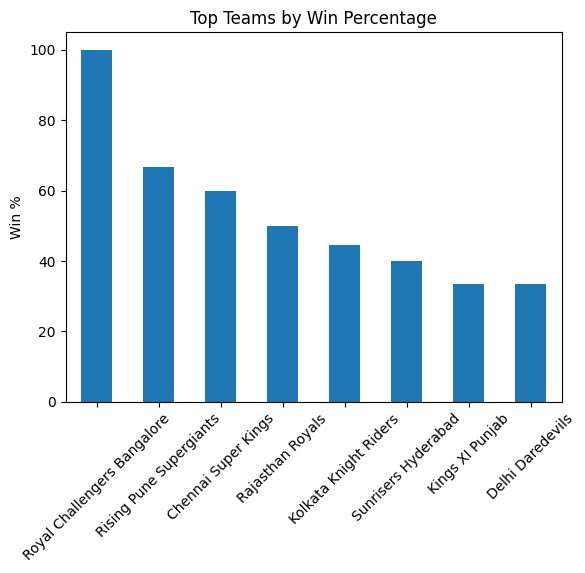

In [13]:
total_matches = matches['team1'].value_counts() + matches['team2'].value_counts()
wins = matches['winner'].value_counts()

win_percentage = (wins / total_matches * 100).sort_values(ascending=False).dropna()

win_percentage.head(10).plot(kind='bar')

plt.title("Top Teams by Win Percentage")
plt.ylabel("Win %")
plt.xticks(rotation=45)
plt.show()

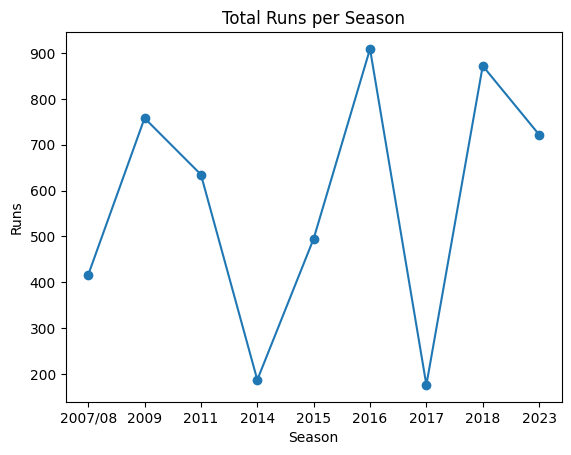

In [16]:
season_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()

# Merge with matches to get season
season_runs = season_runs.merge(matches[['id', 'season']], left_on='match_id', right_on='id')

# Now group by season
season_runs = season_runs.groupby('season')['total_runs'].sum()

season_runs.plot(kind='line', marker='o')

plt.title("Total Runs per Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.show()

In [17]:
player_stats = deliveries.groupby('batter').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
})

player_stats['strike_rate'] = (player_stats['batsman_runs'] / player_stats['ball']) * 100

player_stats.sort_values(by='strike_rate', ascending=False).head(10)

,batsman_runs,ball,strike_rate
batter,,,
L Wood,9,3,300.000000
B Stanlake,5,2,250.000000
J Fraser-McGurk,330,150,220.000000
R Sai Kishore,13,6,216.666667
Umar Gul,39,19,205.263158
RS Sodhi,4,2,200.000000
Shahid Afridi,81,46,176.086957
I Malhotra,7,4,175.000000
WG Jacks,230,133,172.932331


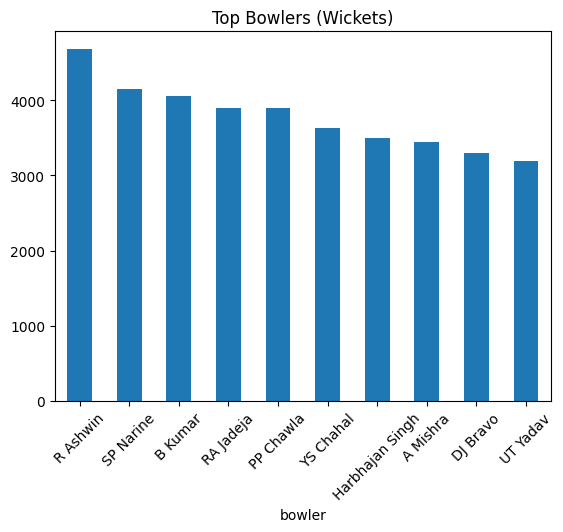

In [18]:
wickets = deliveries['bowler'].value_counts().head(10)

wickets.plot(kind='bar')
plt.title("Top Bowlers (Wickets)")
plt.xticks(rotation=45)
plt.show()

In [20]:
data = pd.merge(matches, deliveries, left_on='id', right_on='match_id')

Mumbai Indians / CSK are most successful teams

Toss has partial influence

Certain players dominate consistently

IPL matches increased over seasons

Batting-first vs chasing trends